In [1]:
import numpy as np
import matplotlib.pyplot as plt
from empymod import bipole
from pygimli.physics.ves import VESModelling, VESRhoModelling
from pygimli.viewer.mpl import drawModel1D

In [2]:
np.logspace(0.5, 3, 40)

array([   3.16227766,    3.66524124,    4.2482017 ,    4.92388263,
          5.70703133,    6.61474064,    7.66682207,    8.88623816,
         10.29960366,   11.93776642,   13.83648068,   16.03718744,
         18.58791891,   21.5443469 ,   24.97099786,   28.94266125,
         33.54602186,   38.8815518 ,   45.06570338,   52.23345074,
         60.54123584,   70.17038287,   81.33105582,   94.26684551,
        109.26008611,  126.63801735,  146.77992676,  170.12542799,
        197.18405565,  228.54638641,  264.89692876,  307.02906298,
        355.86235731,  412.46263829,  478.0652533 ,  554.102033  ,
        642.23254222,  744.38030133,  862.7747686 , 1000.        ])

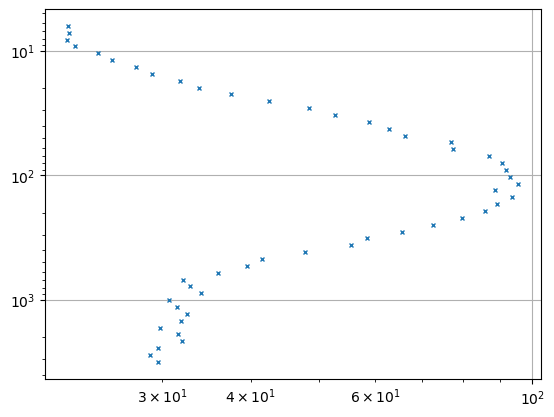

In [3]:
modelSynth = [10, 20, 20, 500, 30]
ab2 = np.logspace(0.8, 3.5, 50)
fBlock = VESModelling(ab2=ab2, mn2=ab2/3, nLayers=3)
error = 0.03
data = fBlock(modelSynth)
data *= np.random.normal(1, error, len(ab2))
fig, ax = plt.subplots()
ax.loglog(data, ab2, "x")
ax.invert_yaxis()
ax.grid()

In [4]:
def Jacobian(model, f):
    J = np.zeros([len(ab2), len(model)])
    responseLog = np.log(f(model))
    for i in range(len(model)):
        modelNew = model.copy()
        modelNew[i] *= 1.1
        J[:, i] = (np.log(f(modelNew))-responseLog) / (np.log(modelNew[i]) - np.log(model[i]))

    return J

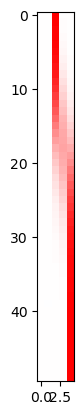

In [5]:
model = np.array([15, 15, 100, 100, 100])
J = Jacobian(model, fBlock)
plt.imshow(J, cmap="bwr", vmin=-1, vmax=1);

In [6]:
model = np.array([15, 15, 100, 100, 100])
I = np.eye(len(model))
lam = 100
for i in range(5):
    response = fBlock(model)
    J = Jacobian(model, fBlock) / error
    dData = (np.log(data) - np.log(response)) / error
    print("chi2 = ", np.mean(dData**2))
    dm = np.linalg.inv(J.T@J + I*lam) @ (J.T@dData)
    model = np.exp(np.log(model) + dm)
    lam *= 0.8

print(model)

chi2 =  976.5711402615677
chi2 =  52.93804919908315
chi2 =  2.0818760428747374
chi2 =  0.9127865028471116
chi2 =  0.9114667119578412
[ 10.1938193   13.89458855  20.4031605  688.91339217  30.22673012]


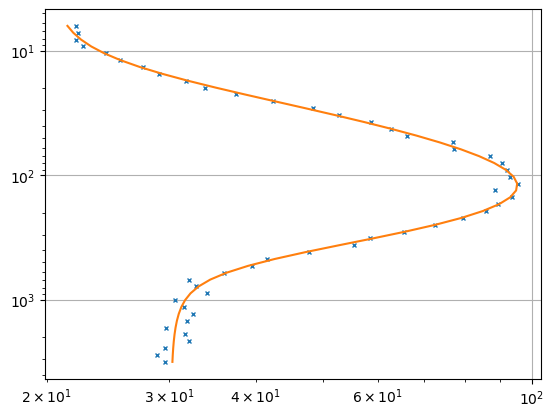

In [7]:
fig, ax = plt.subplots()
ax.loglog(data, ab2, "x", label="data")
ax.loglog(response, ab2, "-", label="response")
ax.invert_yaxis()
ax.grid()

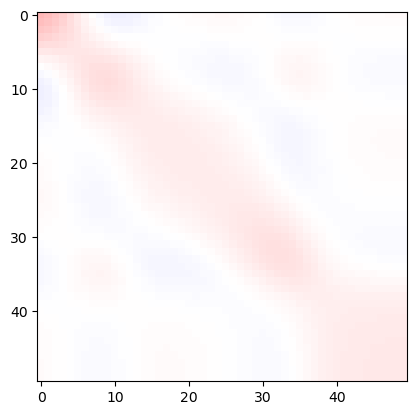

In [8]:
JTJ = J.T@J
MRM = np.linalg.inv(JTJ)@JTJ
DRM = J@np.linalg.inv(JTJ)@J.T
plt.imshow(DRM, cmap="bwr", vmin=-1, vmax=1);

[0.11481178 3.62006372 0.02050791 3.6008115  0.00916765]


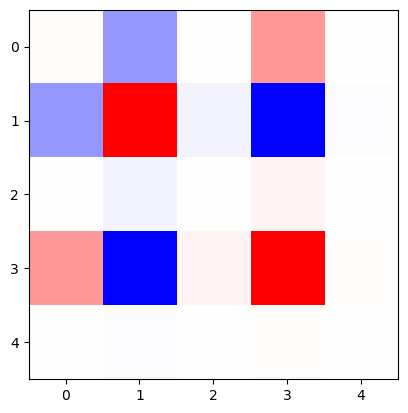

In [9]:
MCM = np.linalg.inv(JTJ)
print(np.sqrt(np.diag(MCM)))
plt.imshow(MCM, cmap="bwr", vmin=-1, vmax=1);

15/07/26 - 09:32:56 - pyGIMLi - INFO - Found 1 regions.


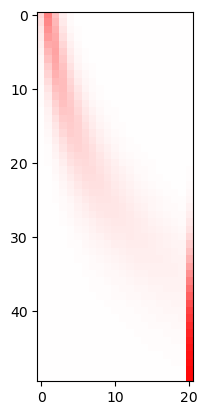

In [10]:
thk = np.linspace(1, 20, 20)
fSmooth = VESRhoModelling(thk, ab2=ab2)
res = np.ones(len(thk)+1) * 100
J = Jacobian(res, fSmooth)
plt.imshow(J, cmap="bwr", vmin=-1, vmax=1);

In [11]:
res = np.ones(len(thk)+1) * 100
C = np.eye(len(res)-1, len(res), 0) - np.eye(len(res)-1, len(res), k=1)
CTC = C.T@C  # only C.T C is needed
lam = 100
for i in range(6):
    response = fSmooth(res)
    J = Jacobian(res, fSmooth) / error
    dData = (np.log(data) - np.log(response)) / error
    print("chi2 = ", np.mean(dData**2))
    dm = np.linalg.inv(J.T@J + CTC*lam) @ (J.T@dData - CTC@np.log(res))
    res = np.exp(np.log(res) + dm)

print(model)

chi2 =  976.5711402615676
chi2 =  16.825213548412638
chi2 =  2.5421429306681533
chi2 =  1.434396882762376
chi2 =  1.2564681760717293
chi2 =  1.1534733759107085
[ 10.1938193   13.89458855  20.4031605  688.91339217  30.22673012]


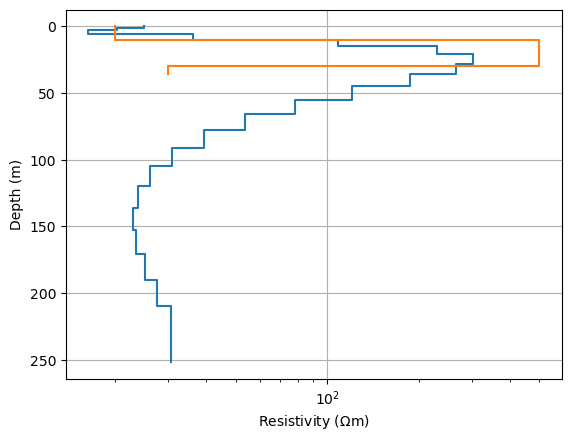

In [38]:
fig, ax = plt.subplots()
drawModel1D(ax, thk, res, plot="semilogx")
drawModel1D(ax, model=modelSynth)
ax.invert_yaxis()

In [13]:
J.shape, C.shape

((50, 21), (20, 21))

[0.0929475  0.03893829 0.04395563 0.05497379 0.07151997 0.07748969
 0.07398139 0.07077986 0.07521626 0.08526811 0.09558668 0.10289509
 0.10604789 0.10527466 0.10185515 0.09785905 0.09532088 0.09453827
 0.09226866 0.07976684 0.01166659]


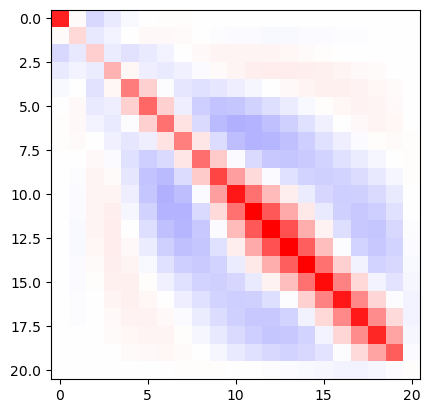

In [30]:
JTJ = J.T@J
MCM = np.linalg.inv(JTJ + CTC*lam)
var = np.sqrt(np.diag(MCM))
print(var)
plt.imshow(MCM, cmap="bwr", vmin=-.01, vmax=.01);

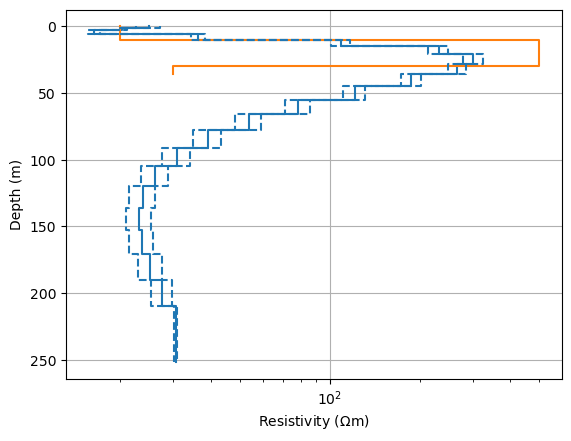

In [36]:
fig, ax = plt.subplots()
drawModel1D(ax, thk, res, plot="semilogx")
drawModel1D(ax, model=modelSynth)
drawModel1D(ax, thk, res*(1+var), color="C0", ls="--")
drawModel1D(ax, thk, res*(1-var), color="C0", ls="--")
ax.invert_yaxis()

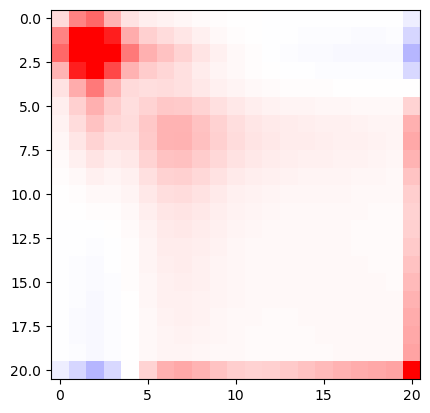

In [25]:
plt.imshow(JTJ, cmap="bwr", vmin=-1000, vmax=1000)

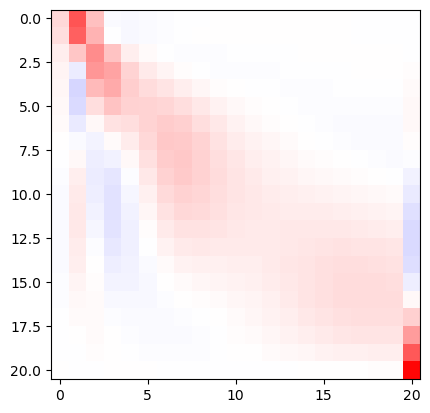

In [34]:
MRM = MCM @ JTJ
plt.imshow(MRM, cmap="bwr", vmin=-1, vmax=1)

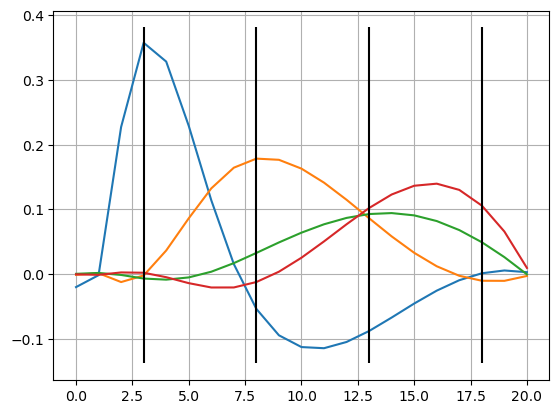

In [17]:
ii = range(3, len(res), 5)
for i in ii:
    plt.plot(MRM[:, i])
plt.vlines(ii, *plt.ylim(), "k")
plt.grid();